# Practical 20

**Aim:** Create various types of plots using Matplotlib: line plot, bar chart, histogram, pie chart, scatter plot using subplots and figure properties.

**Dataset:** Parking Birmingham (UCI Machine Learning Repository, id 482)

### 1. Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('dataset.csv')
df['SystemCodeNumber'] = df['SystemCodeNumber'].astype(str).str.strip()
df['LastUpdated'] = pd.to_datetime(df['LastUpdated'])
df['hour'] = df['LastUpdated'].dt.hour
df.head(2)

,SystemCodeNumber,Capacity,Occupancy,LastUpdated,hour
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42,7
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42,8


### 2. Line Plot, Bar Chart, Histogram, Pie Chart, Scatter Plot using Subplots & Figure Properties

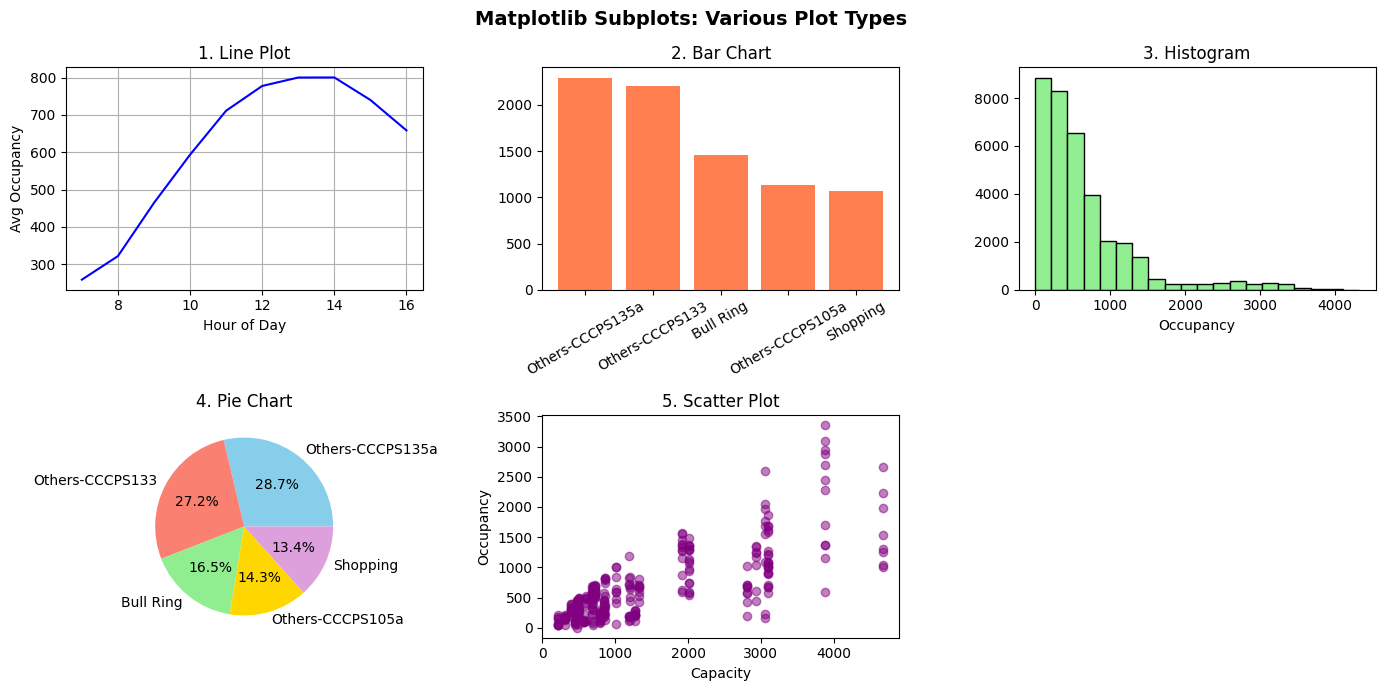

In [2]:
# Prepare aggregated/sample data
hour_occ = df.groupby('hour')['Occupancy'].mean()
top_parks = df.groupby('SystemCodeNumber')['Occupancy'].mean().sort_values(ascending=False).head(5)
park_counts = df.groupby('SystemCodeNumber')['Occupancy'].sum().sort_values(ascending=False).head(5)
sample_df = df.sample(300, random_state=42)

# Create 2x3 Subplots with Figure Properties
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Matplotlib Subplots: Various Plot Types', fontsize=14, fontweight='bold')

# 1. Line Plot
axes[0, 0].plot(hour_occ.index, hour_occ.values, color='blue')
axes[0, 0].set_title('1. Line Plot')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Avg Occupancy')
axes[0, 0].grid(True)

# 2. Bar Chart
axes[0, 1].bar(top_parks.index, top_parks.values, color='coral')
axes[0, 1].set_title('2. Bar Chart')
axes[0, 1].tick_params(axis='x', rotation=30)

# 3. Histogram
axes[0, 2].hist(df['Occupancy'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('3. Histogram')
axes[0, 2].set_xlabel('Occupancy')

# 4. Pie Chart
axes[1, 0].pie(park_counts, labels=park_counts.index, autopct='%1.1f%%',
               colors=['skyblue', 'salmon', 'lightgreen', 'gold', 'plum'])
axes[1, 0].set_title('4. Pie Chart')

# 5. Scatter Plot
axes[1, 1].scatter(sample_df['Capacity'], sample_df['Occupancy'], color='purple', alpha=0.5)
axes[1, 1].set_title('5. Scatter Plot')
axes[1, 1].set_xlabel('Capacity')
axes[1, 1].set_ylabel('Occupancy')

# Remove unused 6th subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()